## Test model performance

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, kendalltau

import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

from sklearn.metrics import (
    f1_score,
    accuracy_score,
    roc_auc_score,
    average_precision_score,
    mean_absolute_error
)

In [ ]:
val_jepa_scores = pd.read_csv("/home/tischuet/zero-shot-deepfake-detection/vit_base_patch32_clip_quickgelu_224_metaclip_400m_Imagenet.csv")

In [ ]:
val_jepa_scores.head()

,label,score,img_path
0,0.0,-889.664429,0_real__0582_class267.png
1,0.0,-631.669189,0_real__1138_class547.png
2,0.0,-537.075195,0_real__0446_class117.png
3,0.0,-436.443604,0_real__1202_class23.png
4,0.0,-874.401672,0_real__0470_class13.png


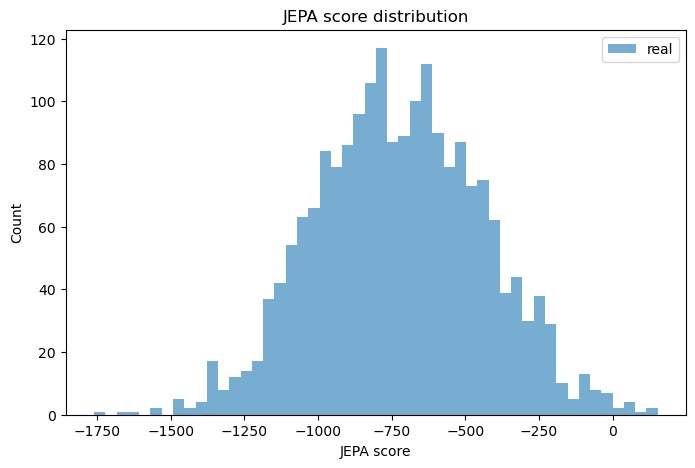

In [ ]:
real_scores = val_jepa_scores.score

plt.figure(figsize=(8,5))

plt.hist(real_scores, bins=50, alpha=0.6, label="real")

plt.xlabel("JEPA score")
plt.ylabel("Count")
plt.title("JEPA score distribution")
plt.legend()

plt.show()

In [ ]:
mean = val_jepa_scores.score.mean(numeric_only=True)
std = val_jepa_scores.score.std(numeric_only=True)

print(f"Mean: {mean}")
print(f"Standard Deviation: {std}")

mean_plus_std = mean + std
print(f"Mean + std threshold for real/fake decision: {mean_plus_std}")

mean_minus_std = mean - std
print(f"Mean - std threshold for real/fake decision: {mean_minus_std}")

percentile = val_jepa_scores.score.quantile(q=0.95)
print(f"95th percentile threshold: {percentile}")

Mean: -722.6715443840027
Standard Deviation: 284.51912577822765
Mean + std threshold for real/fake decision: -438.15241860577504
Mean - std threshold for real/fake decision: -1007.1906701622304
95th percentile threshold: -251.07501983642587


In [ ]:
test_results = pd.read_csv('/home/tischuet/zero-shot-deepfake-detection/vit_large_patch14_clip_quickgelu_224_metaclip_400m_ForenSynths.csv')
test_results.head()

,label,score,img_path
0,1.0,-110.467636,stylegan/car/1_fake/005459.png
1,1.0,-192.005188,stylegan/car/1_fake/005540.png
2,1.0,5.014198,stylegan/car/1_fake/005620.png
3,1.0,-401.952301,stylegan/car/1_fake/005658.png
4,1.0,47.616707,stylegan/car/1_fake/005664.png


In [ ]:
# 0: real and 1: fake
mean_plus_std = 0.0
test_results["prediction_mean_plus_std"] = [1 if f >= mean_plus_std else 0 for f in test_results.score]
test_results["prediction_mean_minus_std"] = [1 if f >= mean_minus_std else 0 for f in test_results.score]
test_results["prediction_percentile"] = [1 if f >= percentile else 0 for f in test_results.score]

In [ ]:
test_results.head()

,label,score,img_path,prediction_mean_plus_std,prediction_mean_minus_std,prediction_percentile
0,1.0,-110.467636,stylegan/car/1_fake/005459.png,0,1,1
1,1.0,-192.005188,stylegan/car/1_fake/005540.png,0,1,1
2,1.0,5.014198,stylegan/car/1_fake/005620.png,1,1,1
3,1.0,-401.952301,stylegan/car/1_fake/005658.png,0,1,0
4,1.0,47.616707,stylegan/car/1_fake/005664.png,1,1,1


In [ ]:
f1_mean_plus_std = f1_score(test_results.label, test_results.prediction_mean_plus_std)
acc_mean_plus_std = accuracy_score(test_results.label, test_results.prediction_mean_plus_std)

f1_mean_minus_std = f1_score(test_results.label, test_results.prediction_mean_minus_std)
acc_mean_minus_std = accuracy_score(test_results.label, test_results.prediction_mean_minus_std)

f1_percentile = f1_score(test_results.label, test_results.prediction_percentile)
acc_percentile = accuracy_score(test_results.label, test_results.prediction_percentile)

ap = average_precision_score(test_results.label, test_results.score)
auc = roc_auc_score(test_results.label, test_results.score)

In [ ]:
print("F1 (mean plus std):", f1_mean_plus_std)
print("Accuracy (mean plus std):", acc_mean_plus_std)

print("F1 (mean minus std):", f1_mean_minus_std)
print("Accuracy (mean minus std):", acc_mean_minus_std)

print("F1 (percentile):", f1_percentile)
print("Accuracy (percentile):", acc_percentile)

print("AUC:", auc)
print("Average precision:", ap)

F1 (mean plus std): 0.7507774223136983
Accuracy (mean plus std): 0.7533461014735024
F1 (mean minus std): 0.6676084255369504
Accuracy (mean minus std): 0.5024632177927354
F1 (percentile): 0.7415011116689378
Accuracy (percentile): 0.6807891153450165
AUC: 0.819368803521686
Average precision: 0.8171398694972128


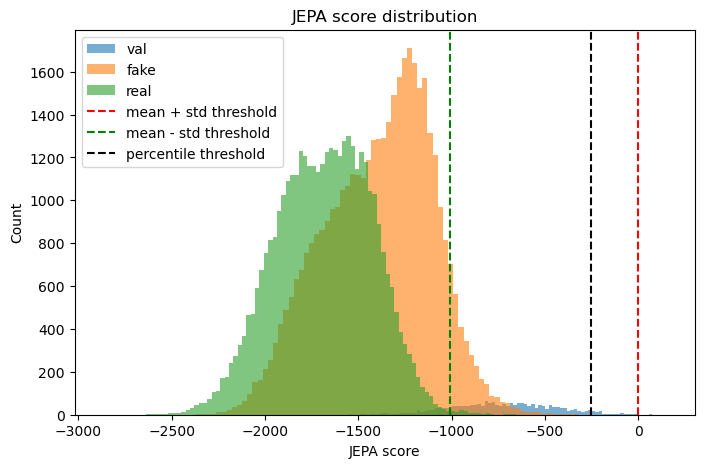

In [ ]:
real_scores = val_jepa_scores.score

plt.figure(figsize=(8,5))

plt.hist(real_scores, bins=100, alpha=0.6, label="val")
plt.hist(test_results[test_results["label"] == 1.0].score, bins=100, alpha=0.6, label="fake")
plt.hist(test_results[test_results["label"] == 0.0].score, bins=100, alpha=0.6, label="real")


plt.axvline(x=mean_plus_std, color="red", linestyle="--", label="mean + std threshold")
plt.axvline(x=mean_minus_std, color="green", linestyle="--", label="mean - std threshold")
plt.axvline(x=percentile, color="black", linestyle="--", label="percentile threshold")

plt.xlabel("JEPA score")
plt.ylabel("Count")
plt.title("JEPA score distribution")
plt.legend()

plt.show()

that fake images have higher values makes sense, as it is a result of more expansion = sparser region

In [ ]:
airplane = test_results[test_results["img_path"].str.contains("airplane")].copy()
airplane

,label,score,img_path,prediction_mean_plus_std,prediction_mean_minus_std,prediction_percentile
41516,1.0,323.188049,progan/airplane/1_fake/00049.png,1,1,1
41517,1.0,493.768433,progan/airplane/1_fake/00069.png,1,1,1
41518,1.0,276.426758,progan/airplane/1_fake/00253.png,1,1,1
41519,1.0,338.734222,progan/airplane/1_fake/00296.png,1,1,1
41520,1.0,372.659485,progan/airplane/1_fake/00305.png,1,1,1
...,...,...,...,...,...,...
41911,0.0,291.577118,progan/airplane/0_real/19497.png,1,1,1
41912,0.0,-348.375092,progan/airplane/0_real/19522.png,0,1,0
41913,0.0,-39.651115,progan/airplane/0_real/19766.png,0,1,1
41914,0.0,-451.895081,progan/airplane/0_real/19776.png,0,1,0


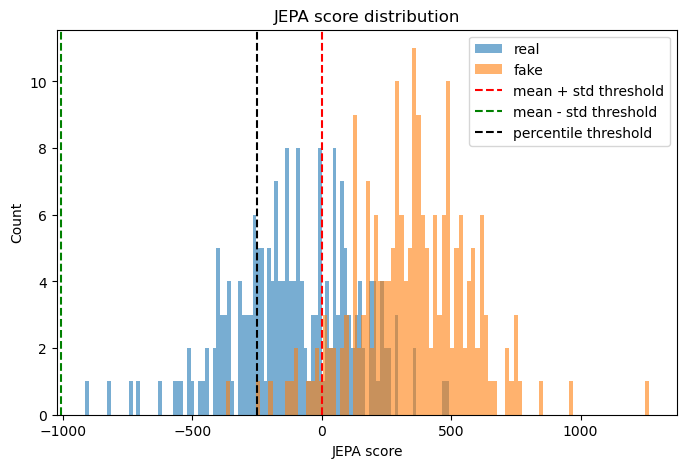

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(airplane[airplane["label"] == 0].score, bins=100, alpha=0.6, label="real")
plt.hist(airplane[airplane["label"] == 1].score, bins=100, alpha=0.6, label="fake")
#plt.hist(real_scores, bins=100, alpha=0.6, label="cal")

plt.axvline(x=mean_plus_std, color="red", linestyle="--", label="mean + std threshold")
plt.axvline(x=mean_minus_std, color="green", linestyle="--", label="mean - std threshold")
plt.axvline(x=percentile, color="black", linestyle="--", label="percentile threshold")

plt.xlabel("JEPA score")
plt.ylabel("Count")
plt.title("JEPA score distribution")
plt.legend()

plt.show()

In [ ]:
base_dir = "/ceph/tischuet/replication_data/ForenSynths"
airplane_sorted = airplane.sort_values(by=["score"])

# Assuming airplane_sorted is already sorted by score
lowest_5 = airplane_sorted.head(5)
highest_5 = airplane_sorted.tail(5)

fig, axes = plt.subplots(2, 5, figsize=(20, 8))

# Top row: lowest 5 scores
for i, (_, row) in enumerate(lowest_5.iterrows()):
    img = mpimg.imread(os.path.join(base_dir, row["img_path"]))
    axes[0, i].imshow(img)
    axes[0, i].set_title(f"Score: {row['score']:.2f}\nLabel: {row['label']}", fontsize=10)
    axes[0, i].set_xlabel(row["img_path"], fontsize=7, wrap=True)
    axes[0, i].axis("off")

# Bottom row: highest 5 scores
for i, (_, row) in enumerate(highest_5.iterrows()):
    img = mpimg.imread(os.path.join(base_dir, row["img_path"]))
    axes[1, i].imshow(img)
    axes[1, i].set_title(f"Score: {row['score']:.2f}\nLabel: {row['label']}", fontsize=10)
    axes[1, i].set_xlabel(row["img_path"], fontsize=7, wrap=True)
    axes[1, i].axis("off")

axes[0, 0].set_ylabel("Lowest 5", fontsize=14, fontweight="bold", labelpad=10)
axes[1, 0].set_ylabel("Highest 5", fontsize=14, fontweight="bold", labelpad=10)

plt.suptitle("Lowest vs Highest Scoring Airplanes", fontsize=16, fontweight="bold")
plt.tight_layout()
#plt.savefig("lowest_vs_highest_5.png", dpi=150, bbox_inches="tight")
plt.show()

NameError: name 'airplane' is not defined